# Black-Scholes Implied Volatility Surface



The Black-Scholes implied volatility surface is a 3D visualization (often shown as a heatmap or mesh plot) that displays the implied volatility $\sigma_{imp}$ extracted from real-market option prices using the Black-Scholes formula, plotted against two variables:
- Strike price $K$ (or moneyness $K/S$) on one axis  
- Time to expiration $T$ on the other axis

**Why it exists**

In the original Black-Scholes model, volatility $\sigma$ is assumed to be a single constant value for all strikes and all maturities. In practice, when you invert the BS formula to solve for $\sigma$ given the actual traded option price, you get a different $\sigma_{imp}$ for every $(K, T)$ pair. These values are not flat — they form a curved surface.

#### Recall

The Black-Scholes Model can be formulated as follow:

$$
C = S_t \Phi(d_1) - K e^{-r t} \Phi(d_2)
$$

$$
\Phi(x) = \int_{-\infty}^{x} \frac{1}{\sqrt{2\pi}} e^{-s^2/2} \, ds
$$

$$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)t}{\sigma \sqrt{t}}
$$

$$
d_2 = d_1 - \sigma \sqrt{t}
$$

**Mathematically, the Black-Scholes formula is a functional, a map from $\mathbb{R}^5 \to \mathbb{R}$:**

$$
BS : (S, K, r, \sigma, T) \mapsto C
$$

**Where:**

- $S \in \mathbb{R}^+$ (spot price)  
- $K \in \mathbb{R}^+$ (strike price)  
- $r \in \mathbb{R}$ (risk-free rate)  
- $\sigma \in \mathbb{R}^+$ (volatility)  
- $T \in \mathbb{R}^+$ (time to expiry) $\mapsto C \in \mathbb{R}^+$ (call option price)



Import the necessary libraries

In [21]:
import numpy as np
import plotly.graph_objects as go

from scipy.stats import norm
from scipy.optimize import newton
from matplotlib import pyplot as plt

In [6]:
def black_scholes_call_option(S, K, T, r, sigma):
  """ Calculate the price of a European call option using the Black-Scholes formula.
  Input parameters:
    S: Current stock price
    K: Strike price
    T: Time to maturity (in years)
    r: Risk-free interest rate (annualized)
    sigma: Volatility of the underlying stock (annualized)
    
  Output:
    call_price: The price of the European call option
  """
  
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)
  call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
  return call_price

#### Example: Pricing an Option with the Black-Scholes Model

WE have defined the computational logic of an Options price based off the Black-Scholes model, via the function above. One thing we can do with this function is produce a price based on five inputs.

**Market-observable inputs**
- $S$: Spot price is given by the market/contract
- $K$: Strike is given by the market/contract
- $r$: Risk-free rate is given by the market/contract
- $T$: Time to maturity is given by the market/contract

In the Black-Scholes framework, given the *stock price*, *strike price*, *risk-free rate*, *time to maturity*, and *volatility*, one can compute the price of a call or put option. But in practice, almost all of these inputs are set by the market: the spot price comes from supply and demand for the underlying (e.g., Apple or Nvidia), the strike is fixed by the option contract, the risk-free rate is market-determined, and the maturity is also predetermined. Even the option price itself is observable from the options chain. That leaves volatility as the only unknown. 

Unlike the other inputs, volatility is not directly observable—we can estimate it from historical returns, but there is no “true” volatility we can look up. This raises the question: what volatility should we plug into Black-Scholes? This is where implied volatility becomes powerful. Since we know four of the five inputs and the market price of the option (the output), we can invert the Black-Scholes formula to solve for the volatility that makes the model’s price match the market price. This implied volatility reflects how traders are collectively pricing future uncertainty.


It seems odd — we already have all of the inputs (except volatility) to the Black-Scholes model. In fact, we also have the option's price — this is dictated by **supply and demand**! in fact, we can guess the implied volatility required to produce the market price of the option under the given parameter set by the market/contract.

In [15]:
S = 100    # Spot price is given by the market/contract
K = 100    # Strike is given by the market/contract
r = 0.05   # Risk-free rate is given by the market/contract
T = 1      # Time to maturity is given by the market/contract

# Thanks to supply and demand, the market price of the call option is given
C = 11.50   # Call option price is given by the market/contract

# Volatility is NOT directly observable. We can proxy for it using a variety of measures, but it isn't directly available.
sigma = 0.2   # ← This is the value we usually solve for (implied volatility)

# Example Black-Scholes call price calculation (using an assumed volatility)
print("The Black-Scholes call option price is $", np.round(black_scholes_call_option(S, K, r, sigma, T), 2))

The Black-Scholes call option price is $ 9.36


If we plug a random volatility—say 20%—into Black-Scholes, we might get an option price of 9.36, which does not match the market price of 11.50. Since option prices rise with volatility and fall when volatility decreases, we can adjust the volatility upward or downward to move closer to the market price. For example, increasing volatility to 50% may overshoot the target. Trying 35%, then 25%, gets progressively closer. But clearly, trial and error is not practical — we cannot just keep guessing until we land on the right number.

Instead, we frame it as a minimization problem: find the volatility that minimizes the difference between the market price and the Black-Scholes price. The volatility that solves this problem is the implied volatility.


We reformulate it as an optimization (minimization) problem, where we search for the volatility $\sigma^*$ that makes the Black-Scholes model price **as close as possible** to the observed market price.

$$
\sigma^* = \arg\min_{\sigma} \bigl( C_{mkt} - C_{BS}(S, K, r, T, \sigma) \bigr)^2
$$

or equivalently (most common formulation):

$$
\sigma^* = \min_{\sigma} \left( C_{mkt} - C_{BS}(\sigma) \right)^2
$$

**where $\sigma^*$ is defined as the Black-Scholes implied volatility.**

**Key Points**
- This is a **least-squares minimization** problem in one dimension ($\sigma$).
- The objective function $f(\sigma) = (C_{mkt} - C_{BS}(\sigma))^2$ is usually smooth, convex (or nearly so) in the relevant range, and has a unique minimum.
- Common numerical methods used in practice:
  - Newton–Raphson (very fast when using vega = $\partial C_{BS}/\partial\sigma$)
  - Bisection method (robust, guaranteed convergence)
  - Brent’s method (hybrid — combines bisection with inverse quadratic interpolation)
  - Secant method

**$\sigma^*$ is called the implied volatility** because it is the volatility value *implied* by the market price when using the Black-Scholes model.

In [17]:
def implied_volatility_call_option(C, S, K, r, T, sigma_init=0.2):
  """ Calculate the implied volatility of a call option using the Newton-Raphson method.
  Input parameters:
    C: Market price of the call option
    S: Current stock price
    K: Strike price
    r: Risk-free interest rate (annualized)
    T: Time to maturity (in years)
    sigma_init: Initial guess for the volatility (default is 0.2)
    
  Output:
    implied_vol: The implied volatility of the European call option
  """
  
  def objective_function(sigma):
    return black_scholes_call_option(S, K, r, sigma, T) - C
  
  implied_vol = newton(objective_function, sigma_init)
  return implied_vol

Let's run the computation

In [19]:
S = 100    # Spot price is given by the market/contract
K = 100    # Strike is given by the market/contract
r = 0.05   # Risk-free rate is given by the market/contract
T = 1      # Time to maturity is given by the market/contract
C = 12.15   # Call option price is given by the market/contract

# Calculate the implied volatility of the call option
implied_vol = implied_volatility_call_option(C, S, K, r, T)
print("The implied volatility of the call option is", np.round(implied_vol, 4))

# Verify that the calculated implied volatility gives us the correct call option price
calculated_call_price = black_scholes_call_option(S, K, r, implied_vol, T)
print("The original call option price from the market is $", C)
print("The call option price calculated using the implied volatility is $", np.round(calculated_call_price, 2))

The implied volatility of the call option is 1.308
The original call option price from the market is $ 12.15
The call option price calculated using the implied volatility is $ 12.15


It match!!!

**(Optional)**

We can visualise how the Newton-Raphson method converges to the IV.

In [23]:
def plot_implied_vol_convergence(C, S, K, r, T, sigma_init=0.2):
  """Plot the convergence steps of Newton-Raphson method for implied volatility"""
  def objective(sigma):
    return (black_scholes_call_option(S, K, r, sigma, T) - C)**2
  
  def derivative(sigma):
    h = 1e-7
    return (objective(sigma + h) - objective(sigma)) / h
    
  # Track convergence steps
  sigmas = []
  errors = []
  sigma = sigma_init
    
  for i in range(10):  # Max 10 iterations
    sigmas.append(sigma)
    error = abs(objective(sigma))
    errors.append(error)
    
    if error < 1e-10:
      break
        
    # Newton-Raphson update
    sigma = sigma - objective(sigma)/derivative(sigma)
  
  # Create the plot
  plt.figure(figsize=(18, 6))
  plt.semilogy(range(len(errors)), errors, 'bo-')
  plt.grid(True, alpha=0.3)
  plt.xlabel('Iteration')
  plt.ylabel('Absolute Error ($)')
  plt.title('Newton-Raphson Convergence for Implied Volatility')
  
  plt.show()

 Plot the convergence for our example

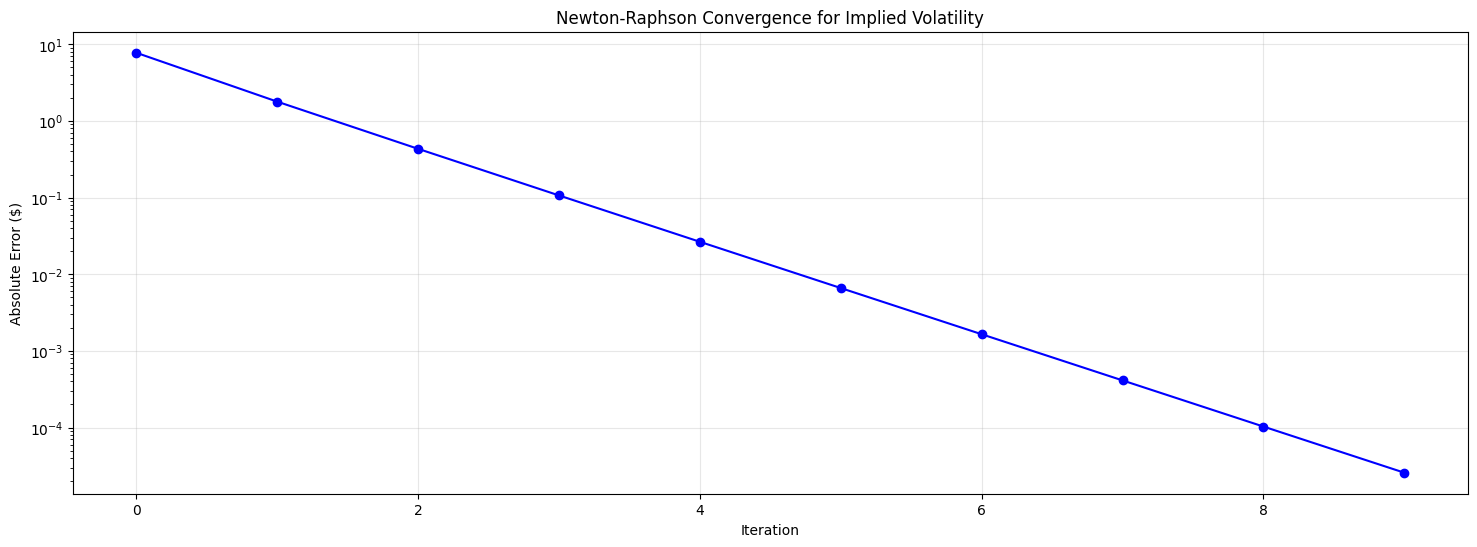

In [24]:
plot_implied_vol_convergence(C=12.15, S=100, K=100, r=0.05, T=1)

Remarks on Implied Volatility & Function Inverses

---

Implied volatilities typically refer to **Black-Scholes Implied Volatilities**, that is, the *inverse* to the Black-Scholes pricing function. Should the context make this distinction necessary, one should clarify whether the implied volatility is being discussed in the context of an alternate model, or specifically referring to the **Black-Scholes model implied volatility**!

Implied volatility uses the current **market price(s)** of the option(s) to inform (or "back out") the volatility parameter of the Black-Scholes model. This gives us insight into the level of volatility (a measure of uncertainty) that traders are using / embedding when pricing these option contracts.

**Functions and their Inverses**

Mathematically, a function (like the Black-Scholes pricing formula) maps a value from the **domain** to a **unique value** in the **range**.

**Example:**
$$
f(x) = 2x \quad \Longrightarrow \quad f(2) = 4
$$

There is no other value of $2$ in the domain that is mapped to anything other than $4$. We know:
- $2$ maps to $4$
- and vice versa: $4$ maps back to $2$ (via the inverse function $f^{-1}(y) = y/2$)

In other words, it doesn’t matter whether we are given a value in the **domain** or in the **range** — as long as the function and its inverse are well-defined, we can move freely back and forth between them.

**This is why Black-Scholes volatility and Black-Scholes prices are used (almost) interchangeably** for fixed contract/market parameters! Once the other parameters ($S$, $K$, $r$, $T$) are fixed, there is a **one-to-one correspondence** between:
- the option price $C$  
- and the implied volatility $\sigma_{imp}$

You can go from price → implied vol, or from implied vol → price, and recover the same value (assuming the function is invertible in the relevant range, which it is for standard call/put options under Black-Scholes assumptions).

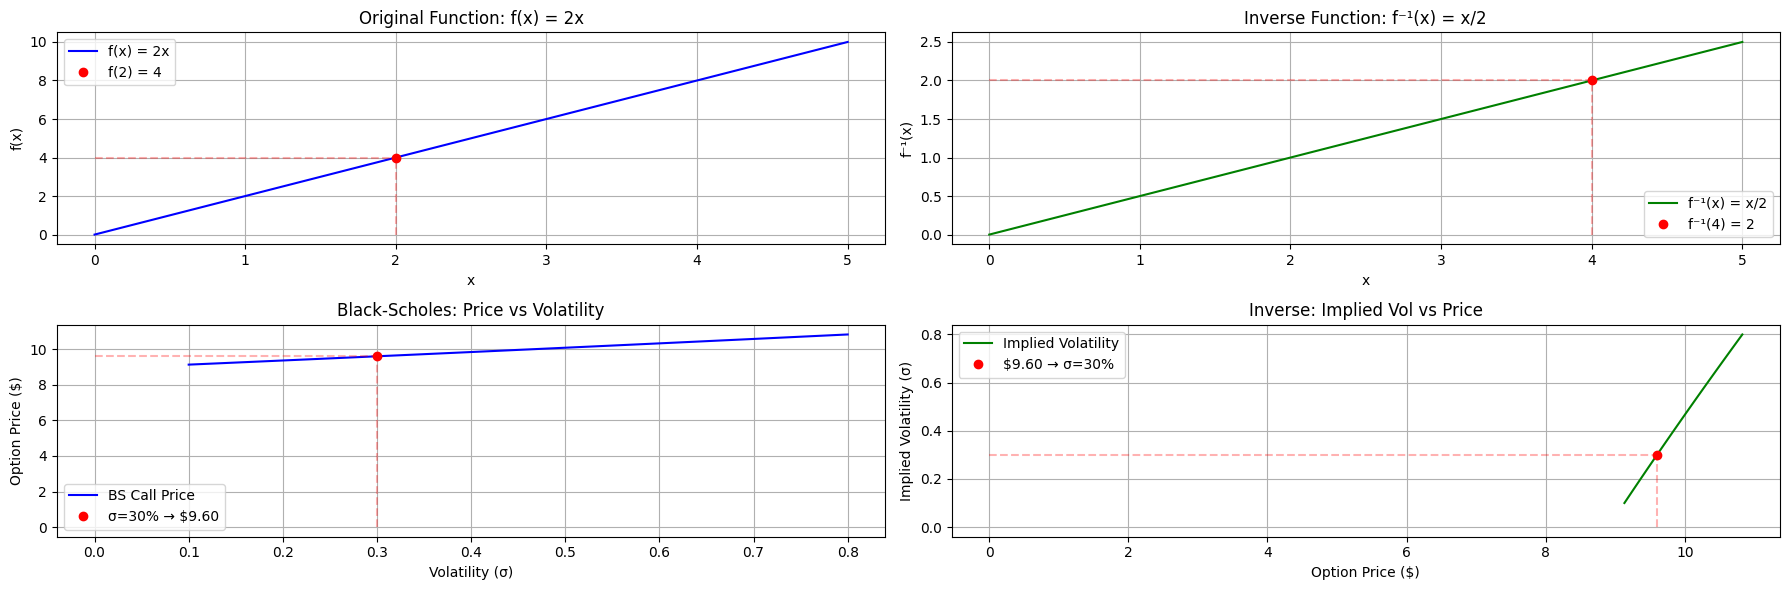

In [26]:
# Create figure with four subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 6))

# Plot f(x) = 2x
x = np.linspace(0, 5, 100)
y = 2*x

ax1.plot(x, y, 'b-', label='f(x) = 2x')
ax1.plot([2], [4], 'ro', label='f(2) = 4')
ax1.plot([2, 2], [0, 4], 'r--', alpha=0.3)
ax1.plot([0, 2], [4, 4], 'r--', alpha=0.3)
ax1.set_title('Original Function: f(x) = 2x')
ax1.grid(True)
ax1.legend()
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')

# Plot inverse function f⁻¹(x) = x/2
ax2.plot(x, x/2, 'g-', label='f⁻¹(x) = x/2')
ax2.plot([4], [2], 'ro', label='f⁻¹(4) = 2')
ax2.plot([4, 4], [0, 2], 'r--', alpha=0.3)
ax2.plot([0, 4], [2, 2], 'r--', alpha=0.3)
ax2.set_title('Inverse Function: f⁻¹(x) = x/2')
ax2.grid(True)
ax2.legend()
ax2.set_xlabel('x')
ax2.set_ylabel('f⁻¹(x)')

# Plot Black-Scholes call price vs volatility
vol = np.linspace(0.1, 0.8, 100)
S = 100
K = 100
r = 0.05
T = 1
price_at_30 = black_scholes_call_option(S, K, r, 0.3, T)
prices = [black_scholes_call_option(S, K, r, v, T) for v in vol]

ax3.plot(vol, prices, 'b-', label='BS Call Price')
ax3.plot([0.3], [price_at_30], 'ro', label=f'σ=30% → ${price_at_30:.2f}')
ax3.plot([0.3, 0.3], [0, price_at_30], 'r--', alpha=0.3)
ax3.plot([0, 0.3], [price_at_30, price_at_30], 'r--', alpha=0.3)
ax3.set_title('Black-Scholes: Price vs Volatility')
ax3.grid(True)
ax3.legend()
ax3.set_xlabel('Volatility (σ)')
ax3.set_ylabel('Option Price ($)')

# Plot implied volatility vs option price by flipping axes
ax4.plot(prices, vol, 'g-', label='Implied Volatility')
ax4.plot([price_at_30], [0.3], 'ro', label=f'${price_at_30:.2f} → σ=30%')
ax4.plot([price_at_30, price_at_30], [0, 0.3], 'r--', alpha=0.3)
ax4.plot([0, price_at_30], [0.3, 0.3], 'r--', alpha=0.3)
ax4.set_title('Inverse: Implied Vol vs Price')
ax4.grid(True)
ax4.legend()
ax4.set_xlabel('Option Price ($)')
ax4.set_ylabel('Implied Volatility (σ)')

plt.tight_layout()
plt.show()

#### The Implied Volatility Surface

**Implied Volatility** is simply the volatility required to produce the equilibrium option price under the Black-Scholes framework — where the market (and contract terms) dictate the rest of the inputs. This allows us to visualize an important concept: **The Implied Volatility Surface**.

**In practice, the implied volatility surface is constructed using:**
- OTM Puts (which often exhibit higher implied volatility)
- ATM Puts / ATM Calls (which should exhibit the **same** implied volatility by Put/Call Parity)
- OTM Calls

… at different **moneyness levels** / **strikes** and **times to maturity**. We get to pick the grid!

**The following is an example of what an equity volatility surface might look like:**
- The **downside** is priced more expensively than the **upside** (fear is on the downside)  
- Something like options on **commodities** may exhibit the same behavior but in the opposite direction (fear is on the upside)

**(Optional)**

The following code generates a sample IV Surface to illustrate the above

In [34]:
# Data for the volatility surface
strikes = [90, 95, 100, 105, 110]
maturities = [1/12, 3/12, 6/12, 1, 2]  # in years
maturity_labels = ['1 Month', '3 Months', '6 Months', '1 Year', '2 Years']

# Volatility values (in %)
vols = np.array([
  [28.0, 24.5, 22.0, 20.5, 19.5],  # 1 month
  [27.5, 24.0, 21.8, 20.3, 19.3],  # 3 months
  [27.0, 23.5, 21.5, 20.0, 19.0],  # 6 months
  [26.5, 23.0, 21.2, 19.8, 18.8],  # 1 year
  [26.0, 22.5, 21.0, 19.5, 18.5]   # 2 years
])

# Create meshgrid for 3D surface
X, Y = np.meshgrid(strikes, maturities)

# Create the 3D surface plot
fig = go.Figure(data=[go.Surface(x=X, y=Y, z=vols, colorscale='viridis')])

# Update layout
fig.update_layout(
  title='Implied Volatility Surface',
  scene=dict(
    xaxis_title='Strike Price',
    yaxis_title='Time to Maturity (Years)',
    zaxis_title='Implied Volatility (%)',
    camera=dict(
      eye=dict(x=1.5, y=1.5, z=1.2)
    )
  ),
  width=1000,
  height=800,
  template='plotly_dark',
  paper_bgcolor='rgb(30,30,30)',
  plot_bgcolor='rgb(30,30,30)'
)

# Show the plot
fig.show()

The above image is an example of an equity implied volatility surface, typically showing a **skew/smile** with higher implied vols for low strikes (OTM puts) and lower vols for high strikes (OTM calls), with some term structure slope along the maturity axis.

For each contract, we solve for implied volatility using its market price, then plot these values in three dimensions: strike (or moneyness), maturity, and implied volatility. If the surface were flat, all options would share the same implied volatility—but in reality, it isn’t. Typically, out-of-the-money puts have higher implied volatilities than out-of-the-money calls, reflecting greater demand for downside protection (a volatility skew). In other markets, such as commodities, the skew may tilt upward instead.

**(Optional)**

The following code is used to generate the **Volatility Skew** and **Term Structure of Volatility** charts.

In [39]:
# Create subplots
fig = go.Figure()
fig2 = go.Figure()

# Plot volatility skew for each maturity
for i, (maturity, label) in enumerate(zip(maturities, maturity_labels)):
  fig.add_trace(go.Scatter(x=strikes, y=vols[i], name=label, mode='lines+markers'))

# Plot term structure for each strike
for i, strike in enumerate(strikes):
  fig2.add_trace(go.Scatter(x=maturities, y=vols[:,i], name=f'Strike {strike}', mode='lines+markers'))

# Update layouts
fig.update_layout(title='Volatility Skew Across Maturities', xaxis_title='Strike Price', yaxis_title='Implied Volatility (%)', width=1000, height=400, showlegend=True)
fig2.update_layout(title='Volatility Term Structure by Strike', xaxis_title='Time to Maturity (Years)', yaxis_title='Implied Volatility (%)', width=1000, height=400, showlegend=True)

# Display plots side by side using subplot
from plotly.subplots import make_subplots
combined_fig = make_subplots(rows=1, cols=2, subplot_titles=("Volatility Skew", "Term Structure of Volatility"))

# Add traces from both figures
for trace in fig.data:
  combined_fig.add_trace(trace, row=1, col=1)
for trace in fig2.data:
  combined_fig.add_trace(trace, row=1, col=2)

# Update layout of combined figure
combined_fig.update_layout(width=1500, height=500, template='plotly_dark', paper_bgcolor='rgb(30,30,30)', plot_bgcolor='rgb(30,30,30)', showlegend=True)

# Show combined plot
combined_fig.show()

#### The Problem (Inconsistent Volatilities, Arbitrage)

The Black-Scholes pricing function is defined as a map:
$$
BS : (S, K, r, \sigma, T) \mapsto C
$$

where:
- $S$ = spot price  
- $K$ = strike price  
- $r$ = risk-free rate  
- $\sigma$ = volatility (assumed **constant** in the model)  
- $T$ = time to maturity  
- $C$ = call option price (or put, depending on context)

**The core inconsistency / problem observed in real markets:**

Even though the Black-Scholes model assumes **a single constant volatility $\sigma$** for all strikes $K$ and all maturities $T$, the **implied volatilities** extracted from **market prices** of different options (different $K$, different $T$) **are not the same** — they vary across the implied volatility surface.

**Key question this creates:**
> Which single volatility $\sigma$ do we pick from the surface if they are different for each market/contract combination?

**Practical implication for trading desks:**

To price **exotic options**, structured products, or new custom options on our own desk, we need a **consistent volatility model** that reproduces **all** observed vanilla option prices (across all strikes and maturities) simultaneously. If we do **not** do this — i.e., if we price different options using inconsistent implied volatilities (or different constant $\sigma$ assumptions) — then we will be **subject to arbitrage**  (other market participants can exploit the pricing inconsistency via combinations of vanillas)

**In short:**
- The Black-Scholes model with **constant $\sigma$** cannot simultaneously match **all** market option prices (because real implied vols form a non-flat surface: smile, skew, term structure).  
- Using different implied vols for different options leads to **inconsistent pricing**.  
- Inconsistent pricing across related instruments → creates **arbitrage opportunities**.  
- Therefore, modern option pricing requires **more advanced models** (local volatility, stochastic volatility, jump-diffusion, etc.) that can be calibrated to reproduce the **entire implied volatility surface** consistently.

This is one of the main motivations for moving beyond the vanilla Black-Scholes model in practice.

#### Example: Mispriced Butterfly Spread (Volatility Arbitrage)

Though not a **pure** butterfly spread, this example illustrates how a flawed constant-volatility assumption creates exploitable mispricing (volatility arbitrage).

**Setup:**

Imagine we are market-making using a **constant volatility Black-Scholes model** with σ = **22.5%** for a stock currently trading at **$100**. We quote two-way markets for the following options (assume same maturity, other parameters fixed):

**Call A (90 strike – OTM put equivalent, downside):**
- Our price (using 22.5% IV): **$12.50**
- Market consensus (real implied vol ≈ **25%**): **$13.20**

→ We are **too cheap** on the 90-strike call (or equivalently, the corresponding OTM put).

**Call B (110 strike – OTM call, upside):**
- Our price (using 22.5% IV): **$4.20**
- Market consensus (real implied vol ≈ **20%**): **$3.80**

→ We are **too expensive** on the 110-strike call.

**A savvy trader could exploit this mispricing as follows:**

1. **Hit our bid** on Call A  
   → buys the cheap downside protection from us (we are offering too low a price given market skew)

2. **Lift our offer** on Call B  
   → sells the expensive upside call to us (we are quoting too high a price given market skew)

3. **Delta-hedge** the position (long/short stock to remain delta-neutral)

**Resulting position characteristics:**

- **Vega-neutral** (or close to it) → the long cheap vol (downside) and short expensive vol (upside) roughly balance in vega terms  
- As time passes and **realized volatility** evolves according to the **market’s implied skew**,  
  → we (the constant-vol market maker) **consistently lose money** on both legs  
  → the counterparty **profits statistically** from our flawed constant-vol assumption

**Key insight:**

The counterparty’s arbitrage is in the **expected value / statistical sense** — not risk-free in the classical deterministic sense, but highly likely to be profitable over many similar trades due to the persistent **volatility skew** in the market.

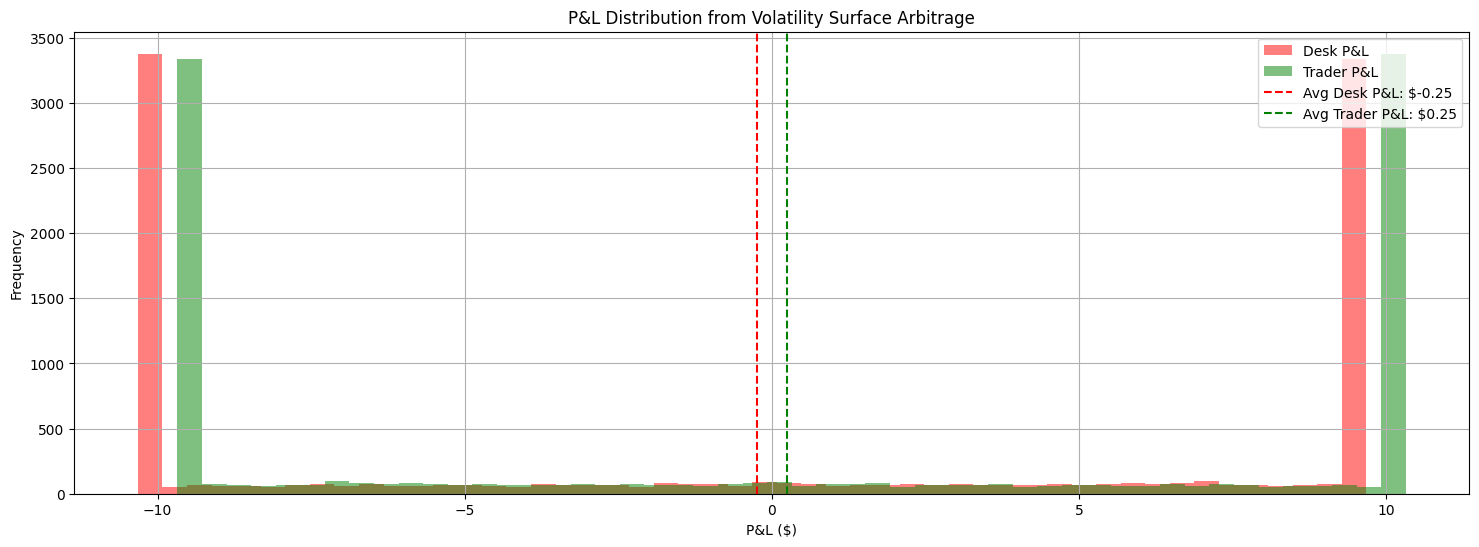

Probability of Desk Loss: 50.0%
Probability of Counterparty Loss: 50.0%
Our Desk EV: $-0.25
Counterparty Desk EV: $0.25


In [40]:
S0 = 100  # Current stock price
K1, K2 = 90, 110  # Strike prices
r = 0.02  # Risk-free rate
T = 1.0  # Time to maturity
n_paths = 10000
n_steps = 252  # Daily steps for a year

# Market vs our volatilities
sigma_market_K1 = 0.25  # 25% IV for K=90
sigma_market_K2 = 0.20  # 20% IV for K=110
sigma_our = 0.225  # Our constant 22.5% vol

# Black-Scholes call price function
def black_scholes_call_option(S, K, T, r, sigma):
  """ Calculate the price of a European call option using the Black-Scholes formula.
  Input parameters:
    S: Current stock price
    K: Strike price
    T: Time to maturity (in years)
    r: Risk-free interest rate (annualized)
    sigma: Volatility of the underlying stock (annualized)
    
  Output:
    call_price: The price of the European call option
  """
  
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
  d2 = d1 - sigma * np.sqrt(T)
  call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
  return call_price

# Calculate initial prices
our_price_K1 = black_scholes_call_option(S0, K1, T, r, sigma_our)
market_price_K1 = black_scholes_call_option(S0, K1, T, r, sigma_market_K1)
our_price_K2 = black_scholes_call_option(S0, K2, T, r, sigma_our)
market_price_K2 = black_scholes_call_option(S0, K2, T, r, sigma_market_K2)

# Generate stock price paths using true market volatility structure
dt = T/n_steps
t = np.linspace(0, T, n_steps+1)
W = np.random.standard_normal((n_paths, n_steps+1))
W[:, 0] = 0

# Use average volatility for demonstration
sigma_realized = (sigma_market_K1 + sigma_market_K2)/2
S = np.zeros((n_paths, n_steps+1))
S[:, 0] = S0

for t in range(1, n_steps+1):
  S[:, t] = S[:, t-1] * np.exp((r - 0.5*sigma_realized**2)*dt + sigma_realized*np.sqrt(dt)*W[:, t])

# Calculate P&L paths
desk_pnl = np.zeros(n_paths)
trader_pnl = np.zeros(n_paths)

for i in range(n_paths):
  # Desk sells K1 call too cheap and buys K2 call too expensive
  desk_pnl[i] = -(max(S[i, -1] - K1, 0) - our_price_K1)  # Loss on K1
  desk_pnl[i] += (max(S[i, -1] - K2, 0) - our_price_K2)  # Loss on K2
  
  # Trader has opposite position
  trader_pnl[i] = -desk_pnl[i]

# Plot results
plt.figure(figsize=(18, 6))
plt.hist(desk_pnl, bins=50, alpha=0.5, label='Desk P&L', color='red')
plt.hist(trader_pnl, bins=50, alpha=0.5, label='Trader P&L', color='green')
plt.axvline(x=np.mean(desk_pnl), color='red', linestyle='--',  label=f'Avg Desk P&L: ${np.mean(desk_pnl):.2f}')
plt.axvline(x=np.mean(trader_pnl), color='green', linestyle='--', label=f'Avg Trader P&L: ${np.mean(trader_pnl):.2f}')
plt.title('P&L Distribution from Volatility Surface Arbitrage')
plt.xlabel('P&L ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

print(f"Probability of Desk Loss: {np.mean(desk_pnl < 0):.1%}")
print(f"Probability of Counterparty Loss: {np.mean(trader_pnl < 0):.1%}")
print(f"Our Desk EV: ${np.mean(desk_pnl):.2f}")
print(f"Counterparty Desk EV: ${np.mean(trader_pnl):.2f}")

We can now simulate the wealth path over time across many different trades

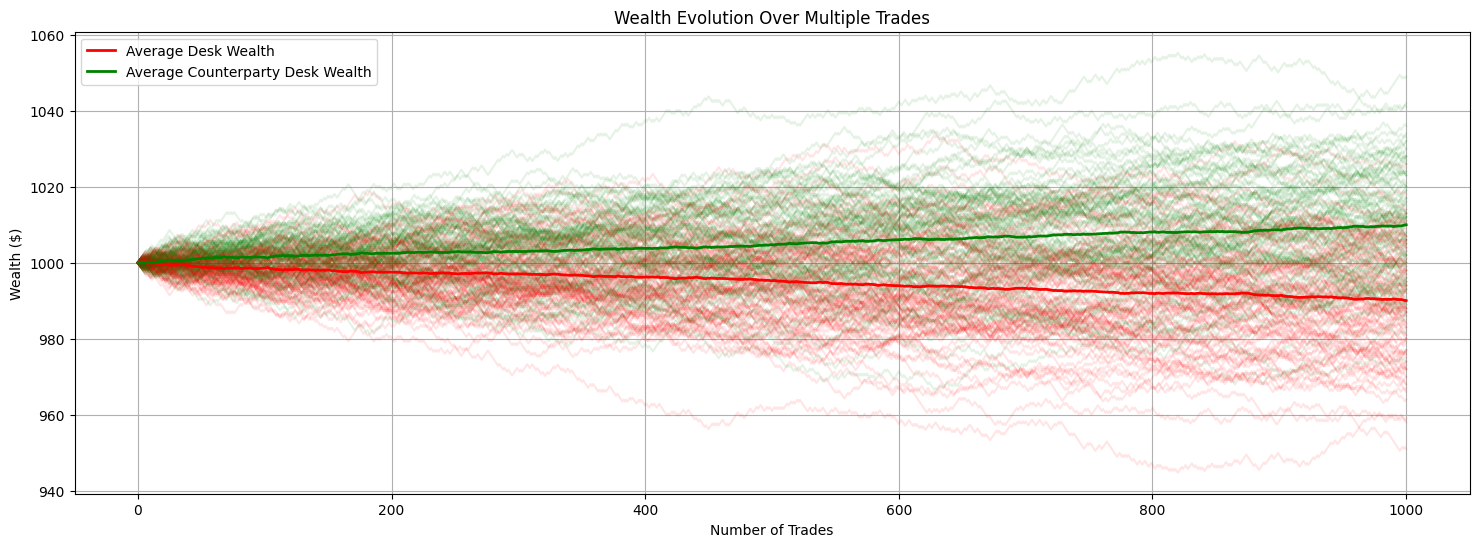

Average Final Desk Wealth: $990.03
Average Final Counterparty Desk Wealth: $1009.97


In [41]:
n_trades = 1000
n_paths = 100
initial_wealth = 1000

# Set parameters from statistics
p_desk_loss = 0.504
desk_ev = -0.25
p_trader_loss = 0.496 
trader_ev = 0.25

# Create arrays to store wealth paths
desk_wealth = np.zeros((n_paths, n_trades+1))
trader_wealth = np.zeros((n_paths, n_trades+1))
desk_wealth[:, 0] = initial_wealth
trader_wealth[:, 0] = initial_wealth

# Simulate paths
for path in range(n_paths):
  for trade in range(n_trades):
    # Generate random outcomes based on probabilities
    desk_outcome = np.random.choice([-1, 1], p=[p_desk_loss, 1-p_desk_loss])
    # Scale outcome to match EV
    if desk_outcome == 1:
      desk_gain = abs(desk_ev/p_desk_loss)
    else:
      desk_gain = -abs(desk_ev/(1-p_desk_loss))
        
    desk_wealth[path, trade+1] = desk_wealth[path, trade] + desk_gain
    trader_wealth[path, trade+1] = trader_wealth[path, trade] - desk_gain

# Plot results
plt.figure(figsize=(18, 6))
trade_nums = np.arange(n_trades+1)

# Plot all paths with low opacity
for path in range(n_paths):
  plt.plot(trade_nums, desk_wealth[path, :], 'r-', alpha=0.1)
  plt.plot(trade_nums, trader_wealth[path, :], 'g-', alpha=0.1)

# Plot means with high opacity
plt.plot(trade_nums, np.mean(desk_wealth, axis=0), 'r-', label='Average Desk Wealth', linewidth=2)
plt.plot(trade_nums, np.mean(trader_wealth, axis=0), 'g-', label='Average Counterparty Desk Wealth', linewidth=2)
plt.title('Wealth Evolution Over Multiple Trades')
plt.xlabel('Number of Trades')
plt.ylabel('Wealth ($)')
plt.legend()
plt.grid(True)
plt.show()

# Print final wealth statistics
print(f"Average Final Desk Wealth: ${np.mean(desk_wealth[:, -1]):.2f}")
print(f"Average Final Counterparty Desk Wealth: ${np.mean(trader_wealth[:, -1]):.2f}")

Remarks:

---

If we compare the wealth paths of a trader transacting with our desk to our own, we may see them consistently making money while we lose. That means they have an edge. If repeated thousands of times, they accumulate positive expected value at our expense—which is unacceptable in a zero-sum derivatives market.To prevent this, our option prices must be arbitrage-free and internally consistent. In practice, pricing isn’t just the risk-neutral value from a model—we also incorporate adjustments and a margin for the market maker. We can’t simply quote whatever a basic formula outputs.

This creates a key requirement: we need a model that generates consistent prices across the entire implied volatility surface. If prices are inconsistent, counterparties can exploit arbitrage opportunities. Since Black-Scholes assumes constant volatility—and the volatility surface clearly varies—we need more advanced models that can handle changing implied volatilities across strikes and maturities.

**The Solution(s)**

Fortunately, we have mamy alternative models for fitting a model parameter set to a volatility surface ensuring consistent prices. Each has benefits and drawbacks - some ensuring the arbitrage free nature of prices, some capturing richer market heuristics and stylized facts, and others trading these for efficiency.

Some **Alternative Models** include:
- Local Volatility (for example, Dupire/Derman)
- Stochastic Volatility (for example, Heston/SABR)
- Jump Diffusion (for example, Merton)
- Rough Models (for example, Gatheral's Rough Bergomi)
- Neural Network Models (for example, Horvath's Deep Learning methodology for approximating pricing functionals)

#### Model Complexity vs Calibration Efficiency

There is always a tradeoff between how rich a model is (how many parameters and dynamics it captures) and how efficiently it can be calibrated to the market volatility surface. More sophisticated models may better reflect reality, but they are typically harder and slower to fit.

**The Calibration Problem**

When pricing an exotic option, we must first calibrate our chosen model—such as a local volatility or stochastic volatility model—to the observed market volatility surface.
Calibration means adjusting the model’s parameters so that, when we use it to price standard options (calls and puts across strikes and maturities), it reproduces their actual market prices. This is conceptually similar to solving for implied volatility in Black-Scholes, except now we are solving for a set of model parameters rather than a single volatility input.

**Why More Advanced Models Are Needed**

The key difference is that models allowing non-constant volatility can replicate the full volatility surface observed in the market. In contrast, Black-Scholes assumes constant volatility, which leads to pricing inconsistencies and potential arbitrage across strikes and maturities. A properly calibrated model that fits the volatility surface will generate consistent, arbitrage-free prices for all listed options—ensuring accurate pricing when quoting exotic derivatives.

Let us take a look at a model example below!

#### Example: Heston Model

The **Heston Model** (1993) is defined by the following system of **Stochastic Differential Equations (SDEs)**:

**Stock Price Process:**
$$
dS(t) = \mu S(t) \, dt + \sqrt{v(t)} \, S(t) \, dW_1(t)
$$

**Variance (Volatility squared) Process** (Ornstein–Uhlenbeck type):
$$
dv(t) = \kappa \bigl( \theta - v(t) \bigr) \, dt + \sigma \sqrt{v(t)} \, dW_2(t)
$$

**Where:**
- $S(t)$ is the stock price at time $t$  
- $v(t)$ is the **instantaneous variance** (volatility squared, $v(t) = \sigma_t^2$)  
- $\mu$ is the **drift** of the stock price (expected return)  
- $\kappa > 0$ is the **speed of mean reversion** of variance  
- $\theta > 0$ is the **long-run (long-term) mean variance**  
- $\sigma > 0$ is the **volatility of variance** (often called “vol of vol”)  

**Correlation between Brownian motions:**

The two Wiener processes $W_1(t)$ and $W_2(t)$ are correlated:

$$
\text{corr}(dW_1(t), dW_2(t)) = \rho \, dt \quad \text{with} \quad -1 \leq \rho \leq 1
$$

Typically $\rho < 0$ in equity markets (negative correlation between returns and volatility → leverage effect / volatility skew).

**Key Features of the Heston Model**
- Volatility is **stochastic** (not constant)  
- Variance follows a **mean-reverting square-root diffusion** process (CIR process) → prevents negative variance  
- Allows for **volatility clustering** and **leverage effect** via $\rho$  
- Capable of generating a **non-flat implied volatility surface** (smile/skew + term structure)  
- Has a **semi-closed-form solution** for European call/put prices via **Fourier inversion** (characteristic function)

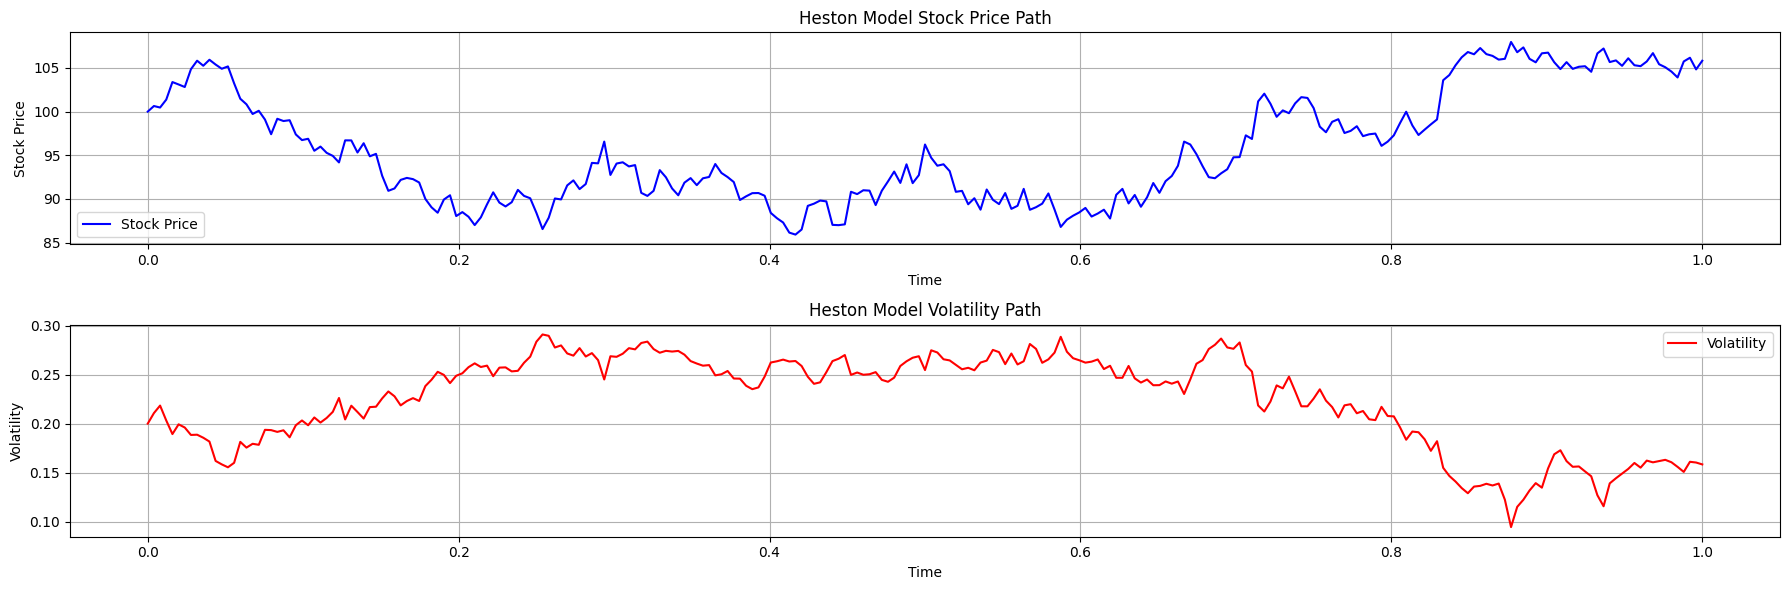

Strike 90: Put Price = 0.8281, Implied Vol = 0.2271
Strike 110: Call Price = 0.8448, Implied Vol = 0.1754

Heston Pricing Functional Market/Contract Parameters:
Initial Stock Price (S0): 100
Risk-free Rate: 5%
Time to Maturity: 0.25 years
Initial Variance (v0): 0.04
Mean Reversion Speed (kappa): 2.0
Long-run Variance (theta): 0.04
Volatility of Variance (sigma): 0.3
Correlation (rho): -0.7


In [42]:
# Set random seed for reproducibility
np.random.seed(42)

# Heston model parameters
v0 = 0.04      # initial variance
kappa = 2.0    # mean reversion speed
theta = 0.04   # long-run variance
sigma = 0.3    # volatility of variance
rho = -0.7     # correlation
S0 = 100       # initial stock price
T = 1.0        # time horizon
N = 252        # number of time steps
dt = T/N       # time step size

# Generate correlated Brownian motions
Z1 = np.random.standard_normal(N)
Z2 = rho * Z1 + np.sqrt(1-rho**2) * np.random.standard_normal(N)

# Initialize arrays
S = np.zeros(N+1)
v = np.zeros(N+1)
t = np.linspace(0, T, N+1)

# Set initial values
S[0] = S0
v[0] = v0

# Simulate paths
for i in range(N):
  v[i+1] = v[i] + kappa*(theta - v[i])*dt + sigma*np.sqrt(v[i]*dt)*Z2[i]
  v[i+1] = max(v[i+1], 0)  # ensure variance stays positive
  S[i+1] = S[i] * np.exp((0.05 - 0.5*v[i])*dt + np.sqrt(v[i]*dt)*Z1[i])

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6))

# Stock price path
ax1.plot(t, S, 'b-', label='Stock Price')
ax1.set_title('Heston Model Stock Price Path')
ax1.set_xlabel('Time')
ax1.set_ylabel('Stock Price')
ax1.grid(True)
ax1.legend()

# Volatility path
ax2.plot(t, np.sqrt(v), 'r-', label='Volatility')
ax2.set_title('Heston Model Volatility Path')
ax2.set_xlabel('Time')
ax2.set_ylabel('Volatility')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Calculate option prices and implied vols for two strikes
K1, K2 = 90, 110  # strikes
T_opt = 0.25      # 3-month option

# Calculate terminal stock prices for many paths
n_paths = 10000
Z1_many = np.random.standard_normal((n_paths, N))
Z2_many = rho * Z1_many + np.sqrt(1-rho**2) * np.random.standard_normal((n_paths, N))

S_paths = np.zeros((n_paths, N+1))
v_paths = np.zeros((n_paths, N+1))
S_paths[:,0] = S0
v_paths[:,0] = v0

# Simulate many paths
for i in range(N):
  v_paths[:,i+1] = v_paths[:,i] + kappa*(theta - v_paths[:,i])*dt + sigma*np.sqrt(v_paths[:,i]*dt)*Z2_many[:,i]
  v_paths[:,i+1] = np.maximum(v_paths[:,i+1], 0)
  S_paths[:,i+1] = S_paths[:,i] * np.exp((0.05 - 0.5*v_paths[:,i])*dt + np.sqrt(v_paths[:,i]*dt)*Z1_many[:,i])

# Calculate option prices from MC simulation
idx_T = int(T_opt/dt)
put_price_K1 = np.mean(np.maximum(K1 - S_paths[:,idx_T], 0)) * np.exp(-0.05*T_opt)
call_price_K2 = np.mean(np.maximum(S_paths[:,idx_T] - K2, 0)) * np.exp(-0.05*T_opt)

# Calculate implied volatilities using Newton's method
def bs_call(S, K, T, r, sigma):
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
  d2 = d1 - sigma*np.sqrt(T)
  return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
  d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T)/(sigma*np.sqrt(T))
  d2 = d1 - sigma*np.sqrt(T)
  return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def implied_vol_put(P, S, K, T, r):
  f = lambda sigma: bs_put(S, K, T, r, sigma) - P
  return newton(f, x0=0.2)

def implied_vol_call(C, S, K, T, r):
  f = lambda sigma: bs_call(S, K, T, r, sigma) - C
  return newton(f, x0=0.2)

impl_vol_K1 = implied_vol_put(put_price_K1, S0, K1, T_opt, 0.05)
impl_vol_K2 = implied_vol_call(call_price_K2, S0, K2, T_opt, 0.05)

print(f"Strike {K1}: Put Price = {put_price_K1:.4f}, Implied Vol = {impl_vol_K1:.4f}")
print(f"Strike {K2}: Call Price = {call_price_K2:.4f}, Implied Vol = {impl_vol_K2:.4f}")
print("\nHeston Pricing Functional Market/Contract Parameters:")
print(f"Initial Stock Price (S0): {S0}")
print(f"Risk-free Rate: 5%")
print(f"Time to Maturity: {T_opt} years")
print(f"Initial Variance (v0): {v0}")
print(f"Mean Reversion Speed (kappa): {kappa}")
print(f"Long-run Variance (theta): {theta}")
print(f"Volatility of Variance (sigma): {sigma}")
print(f"Correlation (rho): {rho}")

Remarks:

---

What we have done above is we have priced two options with spot at 100: a put with strike 90 and a call with strike 110. Both are $10 out of the money. From the volatility surface, we know that out-of-the-money puts are more expensive than out-of-the-money calls because downside risk (“fear”) is priced more heavily. Even without calibrating the Heston model yet, the results already reflect this skew. The put has an implied volatility of 22.71%, while the call has 17.54%. This difference captures the expected volatility skew. Next, we would calibrate the Heston model to the full market volatility surface. Once fitted, it can generate consistent, arbitrage-free prices across strikes and maturities—allowing us to confidently price exotic options and generate profit for the desk.

#### In summary

The implied volatility surface is essential. If our quoted prices are inconsistent with it, counterparties can exploit arbitrage opportunities, leaving us with negative expected value over repeated trade. That is not sustainable for a trading desk.

**What Makes a Good Model?**

With many models available, a few key principles matter:
> 1. Consistent, Arbitrage-Free Pricing: The model must reproduce the observed volatility surface and generate consistent prices—even when extrapolating beyond traded strikes or maturities. This prevents arbitrage and protects the desk from systematic losses.

> 2. Computational Efficiency: Pricing must be fast. A model that requires massive simulations and long runtimes is impractical, no matter how theoretically sound. There is always a tradeoff between model richness (more parameters, more realism) and computational speed. In trading, timely quotes are critical.

> 3. Minimal Unnecessary Assumptions: All models are approximations. The goal is not to perfectly describe the true market distribution, but to make as few assumptions as necessary while still ensuring pricing consistency. Overly restrictive assumptions—like constant volatility in Black-Scholes—can create mispricing and arbitrage risk.

**The Bottom Line**

A good model balances consistency and efficiency. It must align with the market volatility surface, avoid arbitrage, produce prices quickly, and avoid unnecessary assumptions—so the desk maintains a positive edge over many repeated trades.